In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack
import xlens.catalog.model as xmod

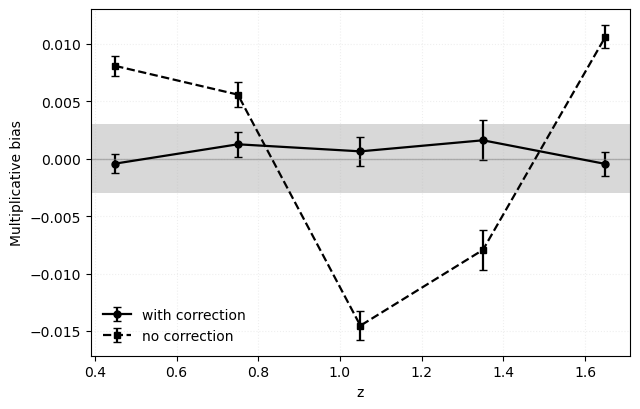

In [2]:
# ----- Data you provided -----
# Case A: with correction
m_with = np.array([ 0.00672190, -0.00042180,  0.00125883,  0.00064408,  0.00160770, -0.00045326])
e_with = np.array([ 0.00191302,  0.00086050,  0.00106381,  0.00128717,  0.00175048,  0.00102416])

# Case B: no correction
m_noc = np.array([-0.01781360,  0.00808597,  0.00558539, -0.01453615, -0.00793715,  0.01063590])
e_noc = np.array([ 0.00183319,  0.00086428,  0.00107293,  0.00124597,  0.00173136,  0.00103328])

# Bin centers (underflow, four bins, overflow):
# underflow (<0.3) at 0.15; then [0.45, 0.75, 1.05, 1.35]; overflow (>=1.5) at 1.65
z_centers = np.array([0.15, 0.45, 0.75, 1.05, 1.35, 1.65])

# ----- Exclude the first (lowest-z) point -----
sl = slice(1, None)  # keep indices 1..end
z_plot   = z_centers[sl]
m_with_p = m_with[sl]
e_with_p = e_with[sl]
m_noc_p  = m_noc[sl]
e_noc_p  = e_noc[sl]

# ----- Plot -----
fig, ax = plt.subplots(figsize=(6.5, 4.2))

# shaded tolerance band |m| < 0.003
ax.axhspan(-0.003, 0.003, facecolor="gray", alpha=0.3, zorder=0)

# with correction: solid black, circle markers
ax.errorbar(
    z_plot, m_with_p, yerr=e_with_p,
    fmt='o', linestyle='-', color='black',
    linewidth=1.6, markersize=5, capsize=3,
    label='with correction'
)

# no correction: dashed black, square markers
ax.errorbar(
    z_plot, m_noc_p, yerr=e_noc_p,
    fmt='s', linestyle='--', color='black',
    linewidth=1.6, markersize=5, capsize=3,
    label='no correction'
)

ax.set_xlabel("z")
ax.set_ylabel("Multiplicative bias")
ax.axhline(0.0, color='gray', linewidth=1, alpha=0.5)
ax.legend(frameon=False)
ax.grid(alpha=0.2, linestyle=':')
fig.tight_layout()
plt.show()

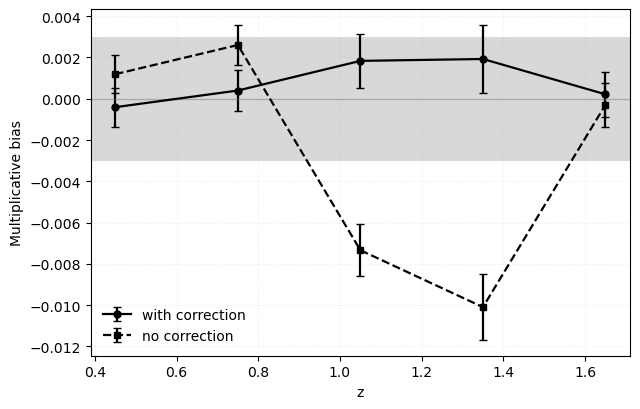

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Previous dataset -----
# Case A: with correction (Paired IDs ≈ 60001)
m_with = np.array([ 0.00284921, -0.00040832,  0.00039839,  0.00183501,  0.00192623,  0.00021475])
e_with = np.array([ 0.00185010,  0.00094040,  0.00100679,  0.00130044,  0.00165915,  0.00107793])

# Case B: no correction (Paired IDs ≈ 60000)
m_noc = np.array([ 0.02291811,  0.00119083,  0.00260456, -0.00734135, -0.01009829, -0.00028923])
e_noc = np.array([ 0.00181625,  0.00091519,  0.00097999,  0.00126199,  0.00159129,  0.00105717])

# Bin centers: underflow, four bins, overflow
z_centers = np.array([0.15, 0.45, 0.75, 1.05, 1.35, 1.65])

# Exclude the first (lowest-z) point
sl = slice(1, None)
z = z_centers[sl]
m_with_p, e_with_p = m_with[sl], e_with[sl]
m_noc_p,  e_noc_p  = m_noc[sl],  e_noc[sl]

# ----- Plot -----
fig, ax = plt.subplots(figsize=(6.5, 4.2))

# shaded tolerance band |m| < 0.003
ax.axhspan(-0.003, 0.003, facecolor="gray", alpha=0.3, zorder=0)

# with correction: solid black + circles
ax.errorbar(
    z, m_with_p, yerr=e_with_p,
    fmt='o', linestyle='-', color='black',
    linewidth=1.6, markersize=5, capsize=3,
    label='with correction'
)

# no correction: dashed black + squares
ax.errorbar(
    z, m_noc_p, yerr=e_noc_p,
    fmt='s', linestyle='--', color='black',
    linewidth=1.6, markersize=5, capsize=3,
    label='no correction'
)

ax.set_xlabel("z")
ax.set_ylabel("Multiplicative bias")
ax.axhline(0.0, color='gray', linewidth=1, alpha=0.5)
ax.legend(frameon=False)
ax.grid(alpha=0.2, linestyle=':')
fig.tight_layout()
plt.show()

In [6]:
data = []
for i in range(10):
    data.append(
        Table.read("/sdf/data/rubin/user/xiangchl/work/2025-10-15/parquet/constant_shear_random/g1/shear02/mode0/group_id=%d/data.parquet" % i)
    )
data = vstack(data)
R = np.average(data["fpfs_e1"] * data["dwsel_dg1"] + data["fpfs_de1_dg1"] * data["wsel"])
e1 = data["fpfs_e1"] * data["wsel"] / R

trace = (data["fpfs_m2"] /  data["fpfs_m0"])
mag = 30.0 - 2.5 * np.log10(data["i_flux_gauss2"])

mag_edges = np.linspace(20.0, 25, 11)
radius_edges  = np.linspace(0.1,  0.7,  7)

/lscratch/xiangchl/ipykernel_2177379/2474575373.py:11: RuntimeWarning: invalid value encountered in log10
  mag = 30.0 - 2.5 * np.log10(data["i_flux_gauss2"])


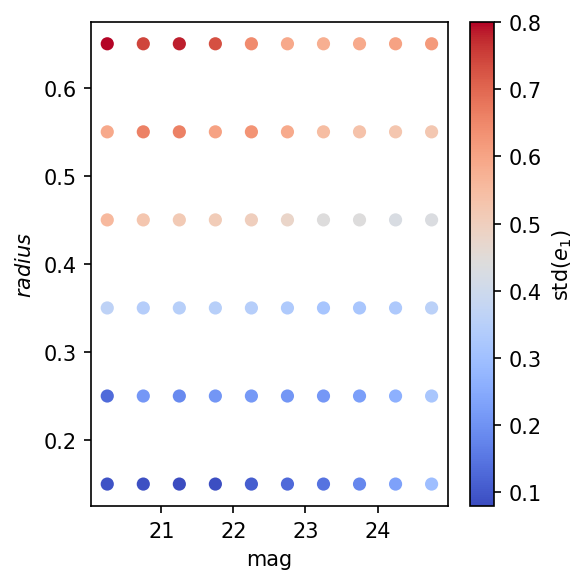

In [8]:
x_array, y_array, z_array, n_array = xmod.estimate_std_in_bins(
    mag=mag, radius=np.sqrt(trace / 2.0), obs=e1,
    mag_edges=mag_edges,
    radius_edges=radius_edges,
)
    
# --- make plot ---
cmap = "coolwarm"
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
sc = ax.scatter(
    x_array,
    y_array,
    c=z_array,
    s=40,
    edgecolor="none",
    cmap=cmap,
)

ax.set_xlabel("mag")
ax.set_ylabel(r"$radius$")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\mathrm{std}(e_1)$")

plt.tight_layout()

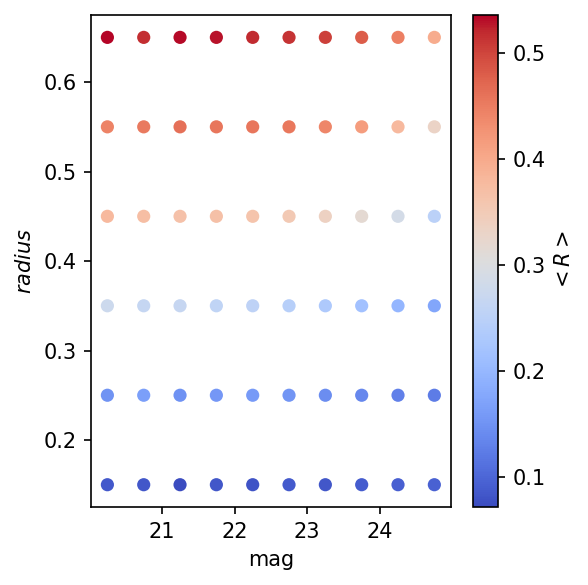

In [7]:
x_array, y_array, m_array, n_array = xmod.estimate_mean_in_bins(
    mag=mag, radius=np.sqrt(trace / 2.0), obs=data["fpfs_de1_dg1"] * data["wsel"],
    mag_edges=mag_edges,
    radius_edges=radius_edges,
)
    
cmap = "coolwarm"
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
sc = ax.scatter(
    x_array,
    y_array,
    c=m_array,
    s=40,
    edgecolor="none",
    cmap=cmap,
)

ax.set_xlabel("mag")
ax.set_ylabel(r"$radius$")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$<R>$")

plt.tight_layout()

In [11]:
n_array

array([   157,    442,   1287,   6415,  13446,   7481,    158,    335,
         4497,  13499,  20889,  12917,    204,   1304,  11924,  27947,
        30896,  21534,    696,   6559,  28222,  47254,  48402,  31266,
          986,  14482,  52806,  74596,  69486,  42149,   2725,  36377,
        90160, 109457, 102536,  61286,   8835,  76374, 156241, 173818,
       144214,  75128,  20287, 144453, 272791, 278352, 203685,  99801,
        36218, 218799, 393009, 389535, 265365, 125847,  56069, 294433,
       511918, 507197, 333640, 151042])

In [12]:
from scipy.optimize import curve_fit

xdata = np.vstack([x_array, y_array])  
p0 = (0.1, 0.1, 0.1, 0.1, 0.1, 0.1)  

popt, pcov = curve_fit(
    xmod.estd_model_fit,
    xdata,
    z_array / np.sqrt(m_array),
    p0=p0,
)

In [13]:
popt

array([ 5.11618976, -0.82583115, 14.71111833,  0.02419886, -2.03779105,
       -0.51938368])

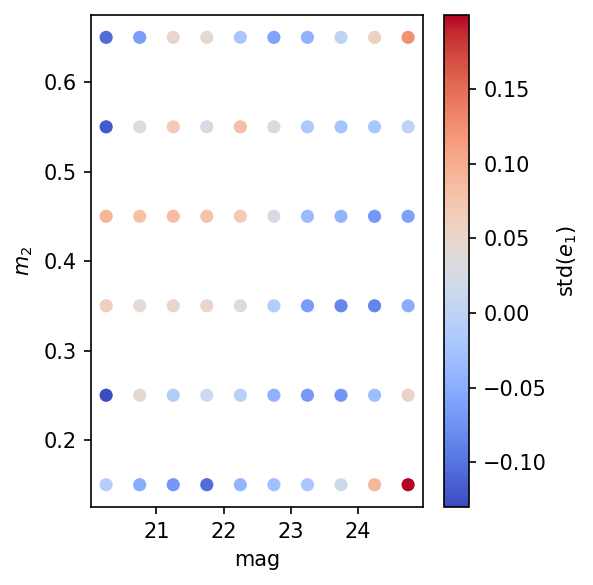

In [16]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
sc = ax.scatter(
    x_array,
    y_array,
    c=z_array / np.sqrt(m_array) - xmod.estd_model_fit(xdata, *popt),
    s=40,
    edgecolor="none",
    cmap=cmap,
)

ax.set_xlabel("mag")
ax.set_ylabel(r"$m_2$")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\mathrm{std}(e_1)$")

plt.tight_layout()

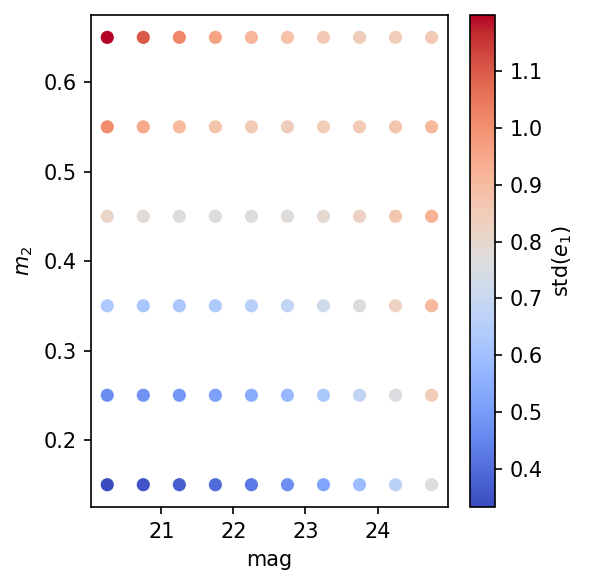

In [17]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
sc = ax.scatter(
    x_array,
    y_array,
    c=xmod.estd_model_fit(xdata, *popt),
    s=40,
    edgecolor="none",
    cmap=cmap,
)

ax.set_xlabel("mag")
ax.set_ylabel(r"$m_2$")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\mathrm{std}(e_1)$")

plt.tight_layout()

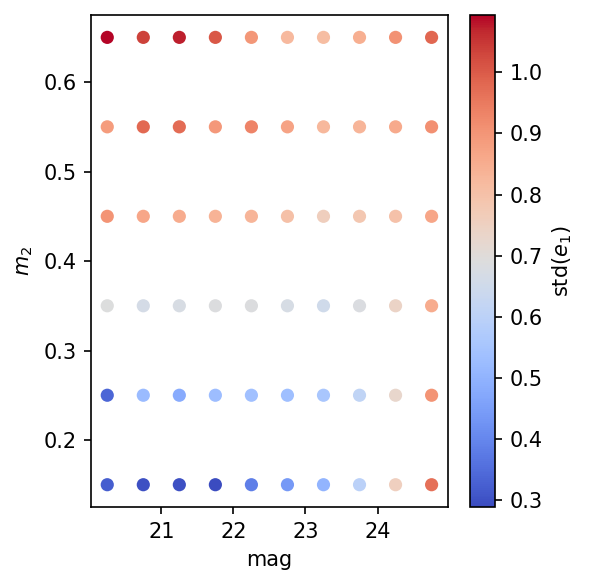

In [18]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
sc = ax.scatter(
    x_array,
    y_array,
    c=z_array / np.sqrt(m_array),
    s=40,
    edgecolor="none",
    cmap=cmap,
)

ax.set_xlabel("mag")
ax.set_ylabel(r"$m_2$")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\mathrm{std}(e_1)$")

plt.tight_layout()

In [ ]:
mask = x_array < 24.5
sigma = z_array[mask]
n = n_array[mask]
sigma2 = sigma**2
N = n.sum()

# combined per-object variance
var_per_obj_equal = (n * sigma2).sum() / N

# variance of the unweighted mean over all objects
np.sqrt(var_per_obj_equal)

In [60]:
sigma = z_array[mask]
n = n_array[mask]
sigma2 = sigma**2

# per-object inverse-variance weight
w = 1.0 / sigma2

# sum of weights over all objects
W = (n * w).sum()

# variance of optimally weighted mean
var_mean_opt = 1.0 / W
np.sqrt(var_mean_opt) * np.sqrt(N)

0.3643050912310898

In [61]:
(0.41 / 0.34) ** 2.0 * 26

37.80795847750865

In [62]:
0.34 * 0.18 / 0.29

0.21103448275862072